<a href="https://colab.research.google.com/github/EdgarNH29/Ciencia-de-Datos-para-Sensores-Inteligentes/blob/main/Practica3_Edgar_Nava_Hernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciencia de datos para sensores inteligentes
## Practica 3 Sensado y análisis inercial
## Edgar Nava Hernandez
El objetivo de este notebook fue desarrollar un pipeline completo para el procesamiento y clasificación de tiros utilizando datos provenientes de sensores inerciales. En esta etapa se trabajó con los datos ya organizados por sujeto e intento, realizando la integración de múltiples archivos CSV en un unico dataset estructurado y coherente. Además, se implementó un procedimiento para manejar sensores faltantes mediante la simulación de señales utilizando estadísticas globales obtenidas exclusivamente del conjunto de entrenamiento, evitando así fuga de información hacia la validación externa.

Se realizo la extracción de características por intento, transformando las señales crudas en variables representativas del movimiento, incluyendo magnitudes de aceleración y giroscopio, métricas estadísticas y características relacionadas con potencia y energía. Cada intento fue resumido en un conjunto de variables que permitiera capturar la dinámica completa del tiro y servir como entrada para los modelos de clasificación.

se entrenaron 5 modelos utilizando únicamente las variables derivadas de los sensores. Se evaluó su desempeño tanto en validación interna como en un conjunto de prueba externo, con el objetivo de analizar su capacidad de generalización ante nuevos datos. El proceso completo permitió construir un sistema estructurado y metodológicamente consistente para la clasificación automática de tiros.

## LEER ARCHIVOS

In [2]:
import os
import pandas as pd
data_path= "drive/MyDrive/CDSI 2026/Inercial/data_inercial"
class_path = "drive/MyDrive/CDSI 2026/Inercial/Tiros_Intentos_Practica_3.csv"
output_path = "drive/MyDrive/Practica3"
clasificacion = pd.read_csv(class_path)

clasificacion.head()

,Sujeto,clase_Tiro,Intento,Nombre Archivo
0,Mariel,0,1,Mariel_01.csv
1,Mariel,0,2,Mariel_02.csv
2,Mariel,1,3,Mariel_03.csv
3,Mariel,0,4,Mariel_04.csv
4,Mariel,0,5,Mariel_05.csv


### Clasifique los archivos de los datos de los sensores:


In [ ]:
import pandas as pd

for archivo in os.listdir(data_path):

    if archivo.endswith(".csv"):

        file_path = os.path.join(data_path, archivo)
        df = pd.read_csv(file_path)

        fila_clase = clasificacion[
            clasificacion["Nombre Archivo"] == archivo
        ]

        if not fila_clase.empty:

            clase = int(fila_clase["clase_Tiro"].values[0])
            sujeto = fila_clase["Sujeto"].values[0]
            intento = int(fila_clase["Intento"].values[0])

            df["Clase_Tiro"] = clase
            df["Sujeto"] = sujeto
            df["Intento"] = intento

            df.to_csv(os.path.join(output_path, archivo), index=False)

            print(f"{archivo} guardado correctamente")

        else:
            print(f"{archivo} NO tiene clasificación asociada")

Mariel_01.csv guardado correctamente
Mariel_02.csv guardado correctamente
Mariel_03.csv guardado correctamente
Mariel_04.csv guardado correctamente
Mariel_05.csv guardado correctamente
Mariel_06.csv guardado correctamente
Mariel_07.csv guardado correctamente
Mariel_08.csv guardado correctamente
Mariel_09.csv guardado correctamente
Mariel_10.csv guardado correctamente
Mariel_11.csv guardado correctamente
Mariel_12.csv guardado correctamente
Mariel_13.csv guardado correctamente
Mariel_14.csv guardado correctamente
Mariel_15.csv guardado correctamente
Mariel_16.csv guardado correctamente
Mariel_17.csv guardado correctamente
Erick_01.csv guardado correctamente
Erick_02.csv guardado correctamente
Erick_03.csv guardado correctamente
Erick_04.csv guardado correctamente
Erick_05.csv guardado correctamente
Erick_06.csv guardado correctamente
Erick_07.csv guardado correctamente
Erick_08.csv guardado correctamente
Erick_09.csv guardado correctamente
Erick_10.csv guardado correctamente
Erick_11.cs

### Unir todos los archivos clasificados en un solo dataset y eliminar las columnas innecesarias:

In [3]:
columnas_excluir = [
    "Pressure (kPa)",
    "Altitude (m)",
    "Temperature (degC)",
    "HeaveMotion (m)"
]

dfs = []

for archivo in os.listdir(output_path):
    if archivo.endswith(".csv"):

        df = pd.read_csv(os.path.join(output_path, archivo))

        df.columns = df.columns.str.strip()

        df = df.drop(columns=[col for col in columnas_excluir if col in df.columns])

        df["Archivo"] = archivo

        dfs.append(df)

dataset_total = pd.concat(dfs, ignore_index=True)

print("Columnas finales:")
print(dataset_total.columns)

Columnas finales:
Index(['SensorId', 'TimeStamp (s)', 'FrameNumber', 'AccX (g)', 'AccY (g)',
       'AccZ (g)', 'GyroX (deg/s)', 'GyroY (deg/s)', 'GyroZ (deg/s)',
       'MagX (uT)', 'MagY (uT)', 'MagZ (uT)', 'EulerX (deg)', 'EulerY (deg)',
       'EulerZ (deg)', 'QuatW', 'QuatX', 'QuatY', 'QuatZ', 'LinAccX (g)',
       'LinAccY (g)', 'LinAccZ (g)', 'Clase_Tiro', 'Sujeto', 'Intento',
       'Archivo'],
      dtype='object')


/tmp/ipython-input-1498509846.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dataset_total = pd.concat(dfs, ignore_index=True)


In [4]:
dataset_total["Clase_Tiro"] = dataset_total["Clase_Tiro"].replace({
    2: 1
})

/tmp/ipython-input-451673399.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset_total["Clase_Tiro"] = dataset_total["Clase_Tiro"].replace({


### calcular estadísticas por Sensor y Clase
Para poder simular los datos faltantes se separo por tiros encestados y tiros no encestados. Se calculo menia y desviacion estandar de estos dos grupos por separado utilizando los datos de dataset_total. Esto me permite crear datos sinteticos para rellenar los sensores faltantes en los archivos en los que no se gravo correctamente

In [5]:
dataset_total["Clase_Tiro"] = dataset_total["Clase_Tiro"].replace({2: 1})

columnas_modelo = [
    "QuatW", "QuatX", "QuatY", "QuatZ",
    "LinAccX (g)", "LinAccY (g)", "LinAccZ (g)",
    "GyroX (deg/s)", "GyroY (deg/s)", "GyroZ (deg/s)"
]

estadisticas_sensores = {}

for clase in dataset_total["Clase_Tiro"].unique():

    df_clase = dataset_total[dataset_total["Clase_Tiro"] == clase]

    for sensor in [2,4,5]:

        df_sensor = df_clase[df_clase["SensorId"] == sensor]

        if len(df_sensor) > 0:

            estadisticas_sensores[(sensor, clase)] = {
                "mean": df_sensor[columnas_modelo].mean(),
                "std": df_sensor[columnas_modelo].std()
            }

In [7]:
dataset_total.shape

(39867, 26)

### Rellenar sensores faltantes por archivo

In [9]:
import numpy as np
sensores_esperados = [2,4,5]

dataset_rellenado = []

for archivo in dataset_total["Archivo"].unique():

    df_archivo = dataset_total[dataset_total["Archivo"] == archivo]

    sensores_presentes = df_archivo["SensorId"].unique()

    for sensor in sensores_esperados:

        if sensor not in sensores_presentes:

            clase = df_archivo["Clase_Tiro"].iloc[0]

            stats = estadisticas_sensores[(sensor, clase)]

            n_muestras = len(df_archivo[df_archivo["SensorId"] == sensores_presentes[0]])

            datos_simulados = pd.DataFrame(
                np.random.normal(
                    loc=stats["mean"].values,
                    scale=stats["std"].values,
                    size=(n_muestras, len(columnas_modelo))
                ),
                columns=columnas_modelo
            )

            datos_simulados["SensorId"] = sensor
            datos_simulados["Clase_Tiro"] = clase
            datos_simulados["Archivo"] = archivo
            datos_simulados["Sujeto"] = df_archivo["Sujeto"].iloc[0]
            datos_simulados["Intento"] = df_archivo["Intento"].iloc[0]

            dataset_rellenado.append(datos_simulados)

dataset_final = pd.concat([dataset_total] + dataset_rellenado, ignore_index=True)

In [10]:
sensores_esperados = [2,4,5]
dataset_rellenado = []

for archivo in dataset_total["Archivo"].unique():

    df_archivo = dataset_total[dataset_total["Archivo"] == archivo]
    sensores_presentes = df_archivo["SensorId"].unique()

    sensor_ref = sensores_presentes[0]
    df_ref = df_archivo[df_archivo["SensorId"] == sensor_ref].copy()

    base_tiempo = df_ref[["TimeStamp (s)", "FrameNumber"]].reset_index(drop=True)
    n_muestras = len(base_tiempo)

    for sensor in sensores_esperados:

        if sensor not in sensores_presentes:

            clase = df_archivo["Clase_Tiro"].iloc[0]
            stats = estadisticas_sensores[(sensor, clase)]

            datos_simulados = pd.DataFrame(
                np.random.normal(
                    loc=stats["mean"].values,
                    scale=stats["std"].values,
                    size=(n_muestras, len(columnas_modelo))
                ),
                columns=columnas_modelo
            )

            datos_simulados = pd.concat([base_tiempo, datos_simulados], axis=1)

            datos_simulados["SensorId"] = sensor
            datos_simulados["Clase_Tiro"] = clase
            datos_simulados["Archivo"] = archivo
            datos_simulados["Sujeto"] = df_archivo["Sujeto"].iloc[0]
            datos_simulados["Intento"] = df_archivo["Intento"].iloc[0]

            dataset_rellenado.append(datos_simulados)

dataset_final = pd.concat([dataset_total] + dataset_rellenado, ignore_index=True)

dataset_final = dataset_final.sort_values(
    by=["Archivo", "SensorId", "TimeStamp (s)"]
).reset_index(drop=True)


In [11]:
dataset_final = dataset_final.sort_values(
    by=["Archivo", "SensorId"]
).reset_index(drop=True)

In [12]:
dataset_final.head()

,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Clase_Tiro,Sujeto,Intento,Archivo
0,2,0.00,0,NaN,NaN,NaN,254.367456,-64.623362,287.083778,NaN,...,-0.121466,0.185991,0.044882,-0.233381,3.248574,1.277690,0,Edgar,1,Edgar_01.csv
1,2,0.01,1,NaN,NaN,NaN,-427.274106,238.528301,-316.542865,NaN,...,-0.847859,0.174581,0.312193,2.015820,-0.184900,1.261239,0,Edgar,1,Edgar_01.csv
2,2,0.02,2,NaN,NaN,NaN,-400.586194,-78.443432,-198.669759,NaN,...,-0.084134,-0.813531,0.107497,-0.563645,-1.398888,-1.407327,0,Edgar,1,Edgar_01.csv
3,2,0.03,3,NaN,NaN,NaN,253.767859,-52.340231,-665.863820,NaN,...,-0.823387,0.299622,-0.164375,-2.445886,2.786487,0.375093,0,Edgar,1,Edgar_01.csv
4,2,0.04,4,NaN,NaN,NaN,62.184750,-156.495391,245.067695,NaN,...,0.827099,-1.383455,0.213794,1.380907,1.039838,2.306157,0,Edgar,1,Edgar_01.csv


Se puede corroborar que cada archivo tiene el mismo numero de lecturas en todos los sensores. Sin embargo se sigue manteniendo esa variabilidad ya que solo se empataron los datos por archivo, es decir por tiro

In [13]:
dataset_final.groupby(["Archivo","SensorId"])["TimeStamp (s)"].count()

Archivo       SensorId
Edgar_01.csv  2           141
              4           141
              5           141
Edgar_02.csv  2           123
              4           123
                         ... 
Zarif_18.csv  4           184
              5           184
Zarif_19.csv  2           140
              4           140
              5           140
Name: TimeStamp (s), Length: 333, dtype: int64

Lo que se hizo hasta ahora es calcular estadisticas de los sensores cuando se encesta y cuando se falla, esto me permite simular los datos faltantes de los sensores cuando se encesta y cuando no. Ademas se descartaron los datos que no voy a usar por ejemplo si voy a usar cuaterniones no necesito Euler. Al final solo copie los datos de TimeStamp Y FrameNumber a de los sensores que si existen a los datos simulados de los sensores, asi los datos simulados estaran sincronizados en el tiempo.

## Extraccion de caracteristicas de potencia
Se procesan los datos para pasar de señales crudas a variables biomecánicas:

-Potencia máxima

-Potencia promedio

-Velocidad angular máxima

-Forma de la curva

-Percentiles

-Momento del pico

-Estabilidad antes del pico

-Relación Gyro / LinAcc

Crear magnitudes físiscas

In [14]:
features = []

sensores = [2,4,5]

for archivo in dataset_final["Archivo"].unique():
    df_archivo = dataset_final[dataset_final["Archivo"] == archivo].copy()

    clase = df_archivo["Clase_Tiro"].iloc[0]
    sujeto = df_archivo["Sujeto"].iloc[0]
    intento = df_archivo["Intento"].iloc[0]

    feat_archivo = {
        "Archivo": archivo,
        "Sujeto": sujeto,
        "Intento": intento,
        "Clase_Tiro": clase
    }

    df_archivo["LinAcc_mag"] = np.sqrt(df_archivo["LinAccX (g)"]**2 + df_archivo["LinAccY (g)"]**2 + df_archivo["LinAccZ (g)"]**2)
    df_archivo["Gyro_mag"] = np.sqrt(df_archivo["GyroX (deg/s)"]**2 + df_archivo["GyroY (deg/s)"]**2 + df_archivo["GyroZ (deg/s)"]**2)

    for sensor in sensores:
        df_sensor = df_archivo[df_archivo["SensorId"] == sensor]

        if len(df_sensor) == 0:
            continue

        linacc = df_sensor["LinAcc_mag"].values
        gyro = df_sensor["Gyro_mag"].values
        time = df_sensor["TimeStamp (s)"].values

        feat_archivo[f"Sensor{sensor}_Max_LinAcc"] = linacc.max()
        feat_archivo[f"Sensor{sensor}_Mean_LinAcc"] = linacc.mean()
        feat_archivo[f"Sensor{sensor}_Std_LinAcc"] = linacc.std()

        feat_archivo[f"Sensor{sensor}_Max_Gyro"] = gyro.max()
        feat_archivo[f"Sensor{sensor}_Mean_Gyro"] = gyro.mean()
        feat_archivo[f"Sensor{sensor}_Std_Gyro"] = gyro.std()

        feat_archivo[f"Sensor{sensor}_P25_LinAcc"] = np.percentile(linacc, 25)
        feat_archivo[f"Sensor{sensor}_P75_LinAcc"] = np.percentile(linacc, 75)

        feat_archivo[f"Sensor{sensor}_P25_Gyro"] = np.percentile(gyro, 25)
        feat_archivo[f"Sensor{sensor}_P75_Gyro"] = np.percentile(gyro, 75)

        idx_max_linacc = linacc.argmax()
        feat_archivo[f"Sensor{sensor}_TimeMax_LinAcc"] = time[idx_max_linacc]

        idx_max_gyro = gyro.argmax()
        feat_archivo[f"Sensor{sensor}_TimeMax_Gyro"] = time[idx_max_gyro]

        pre_window = linacc[max(0, idx_max_linacc-10):idx_max_linacc]
        feat_archivo[f"Sensor{sensor}_StabilityPre_LinAcc"] = pre_window.std() if len(pre_window)>0 else 0

        ratio = gyro / np.where(linacc==0, 1e-6, linacc)
        feat_archivo[f"Sensor{sensor}_Mean_GyroLinAcc_Ratio"] = ratio.mean()
        feat_archivo[f"Sensor{sensor}_Std_GyroLinAcc_Ratio"] = ratio.std()

        feat_archivo[f"Sensor{sensor}_Integral_LinAcc"] = np.trapezoid(linacc, time)
        feat_archivo[f"Sensor{sensor}_MaxSlope_LinAcc"] = np.max(np.gradient(linacc, time))

        feat_archivo[f"Sensor{sensor}_Integral_Gyro"] = np.trapezoid(gyro, time)
        feat_archivo[f"Sensor{sensor}_MaxSlope_Gyro"] = np.max(np.gradient(gyro, time))

    features.append(feat_archivo)

dataset_features = pd.DataFrame(features)

Visualizar diferencia encesto vs fallo : Se graficaron histogramas de comparacion entre las estadisticas de los tiros encestados y los no encestados. Esto con el fin de ver si estas graficas nos muestran alguna diferencia en las metricas de las variables que se quieren utilizar para entrenar el modelo

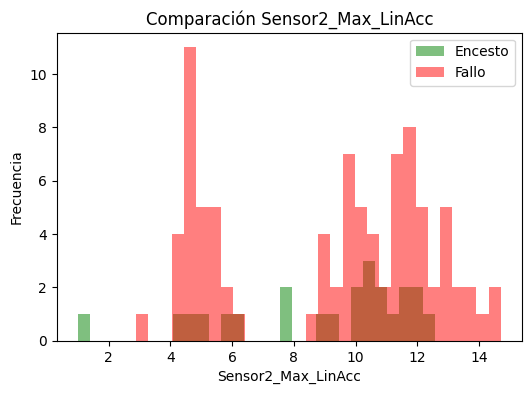

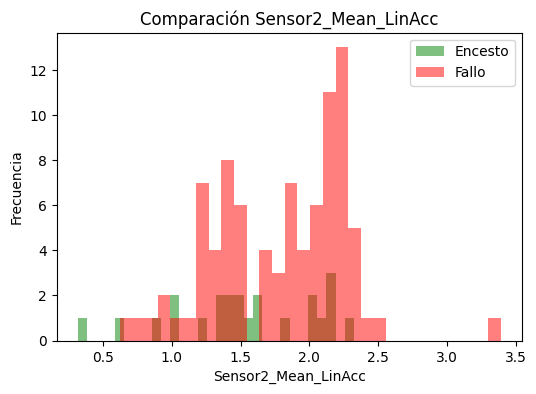

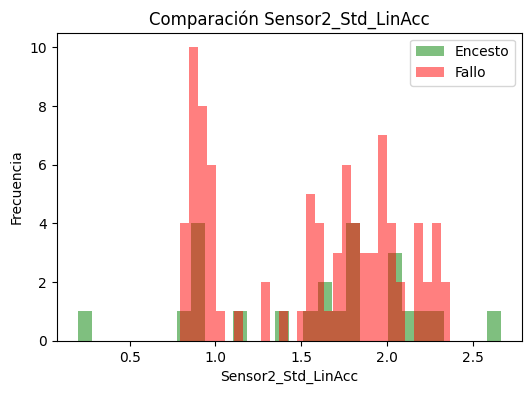

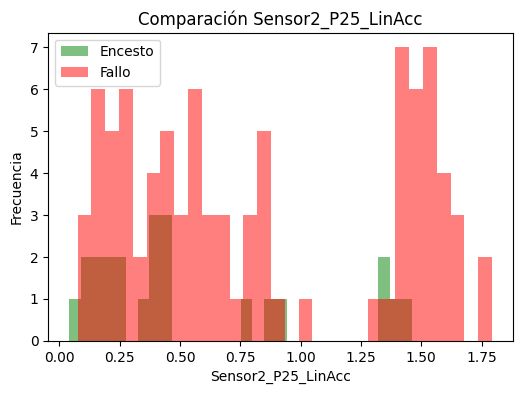

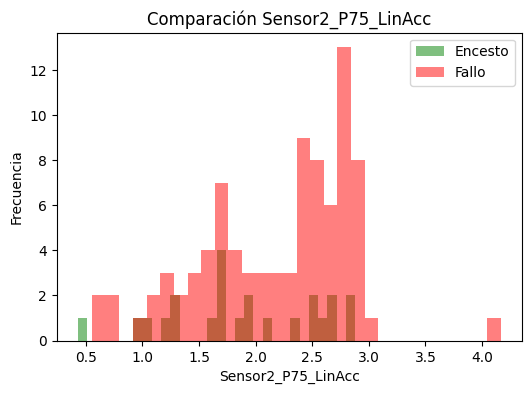

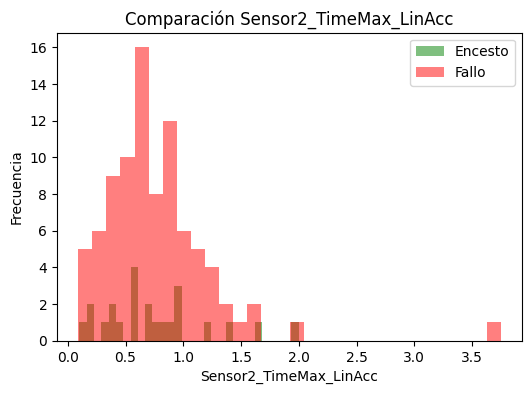

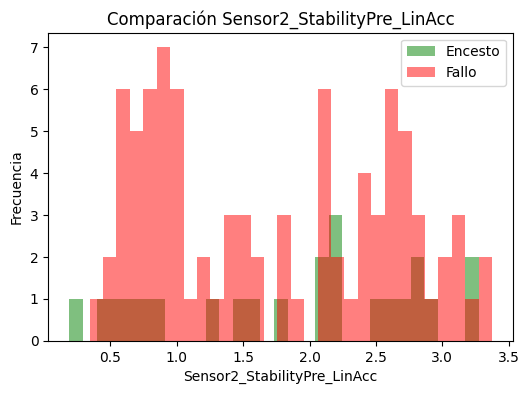

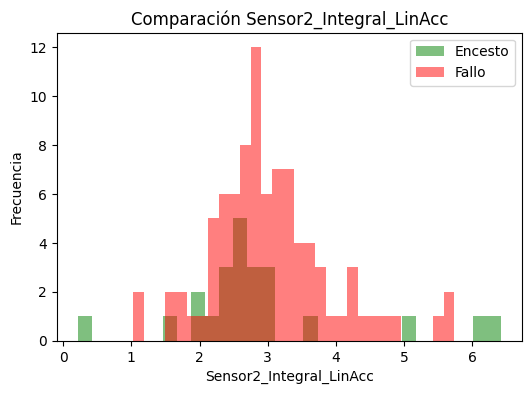

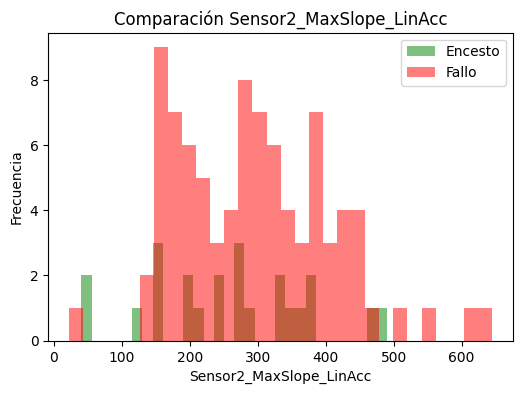

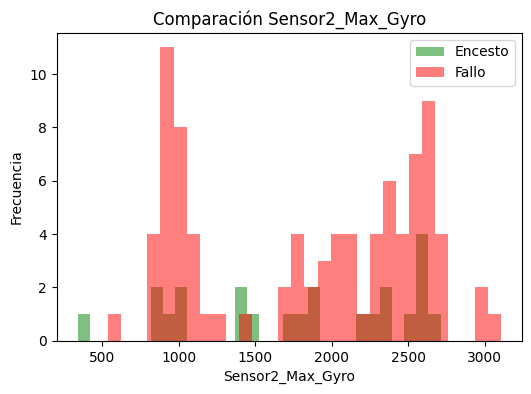

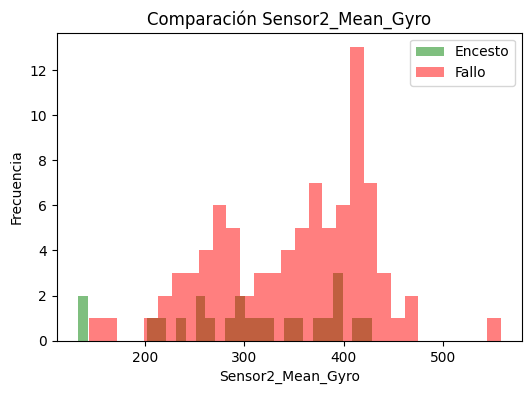

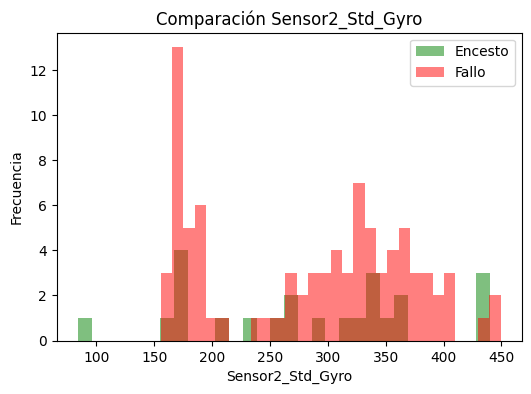

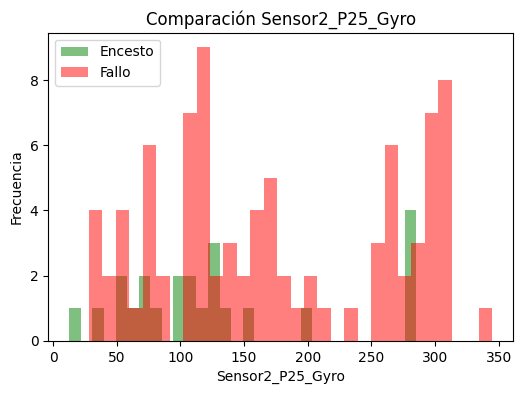

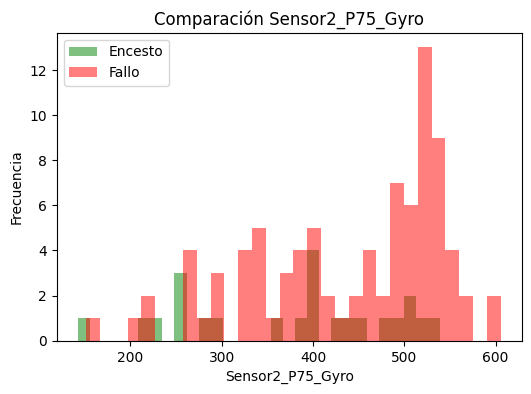

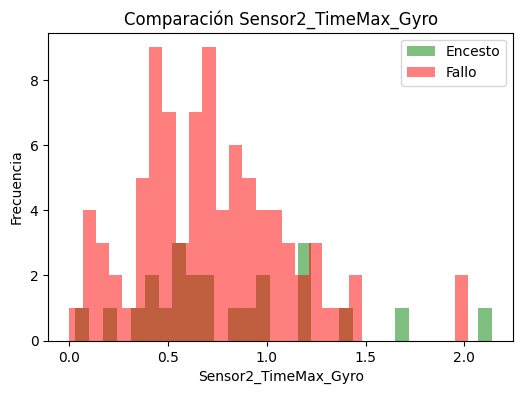

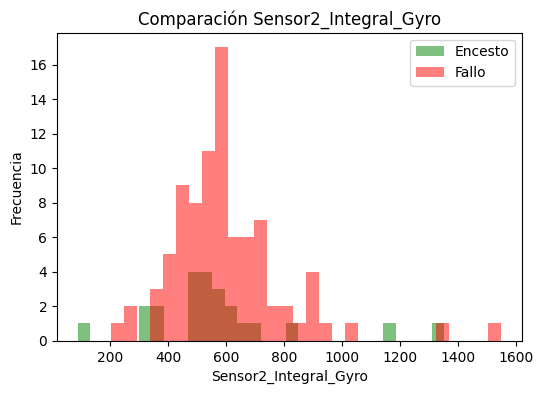

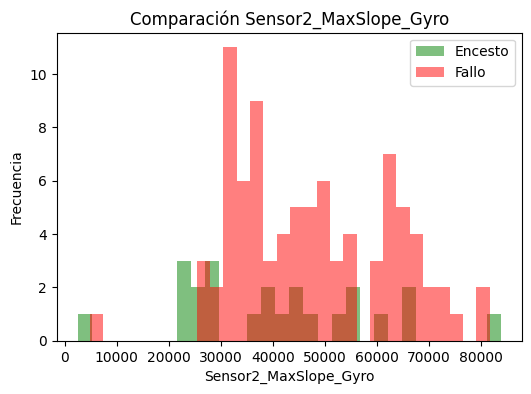

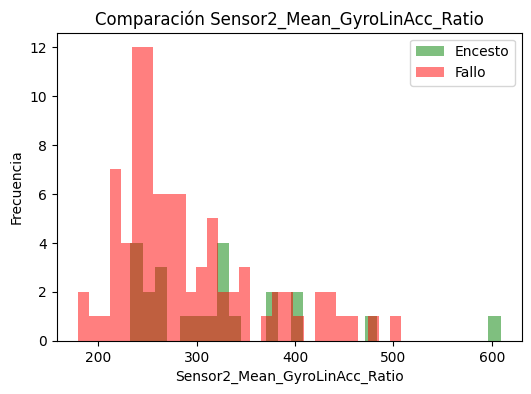

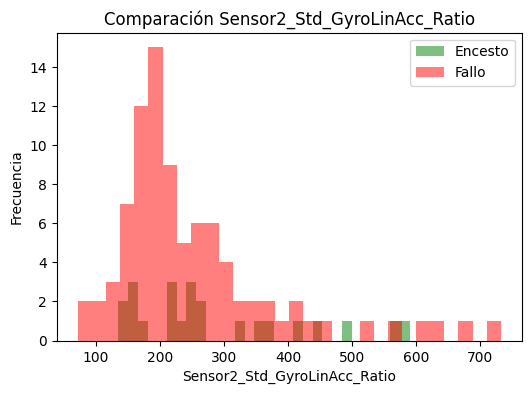

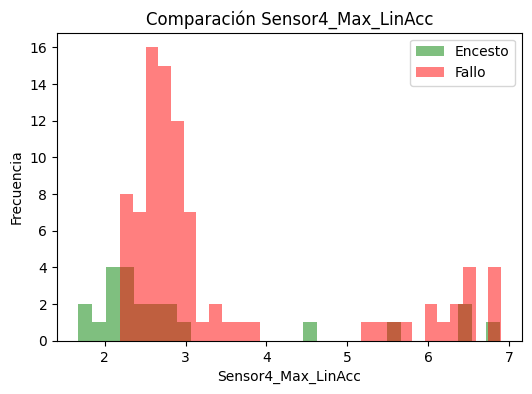

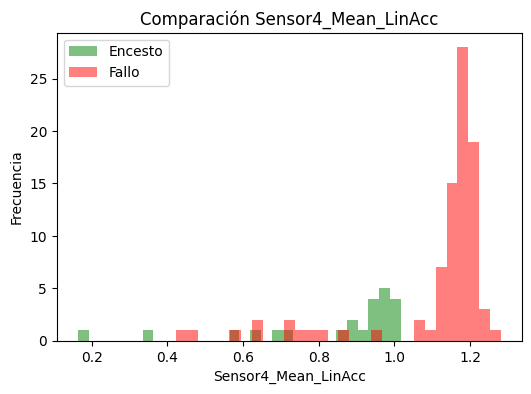

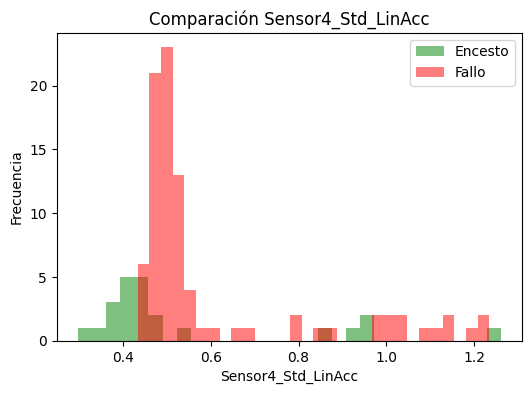

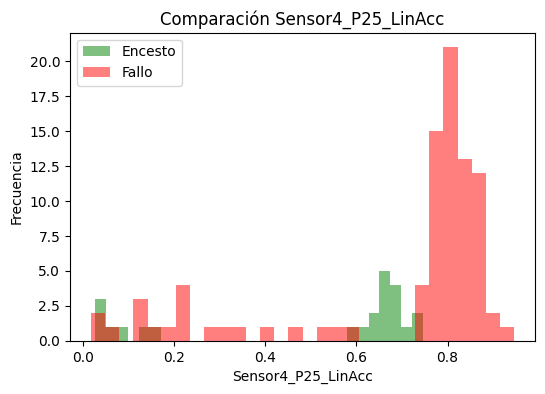

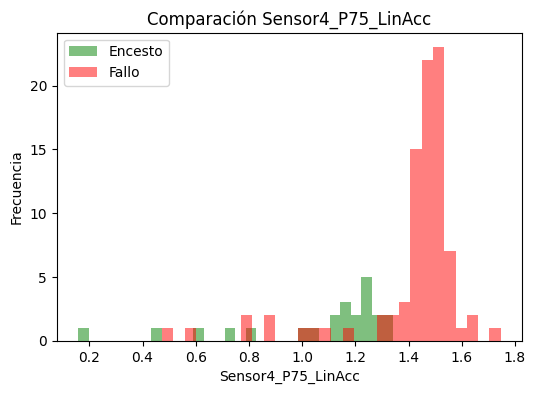

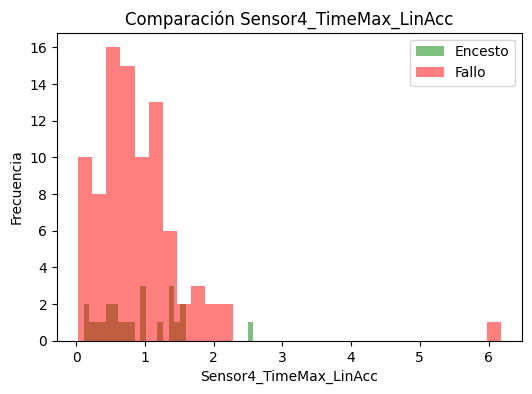

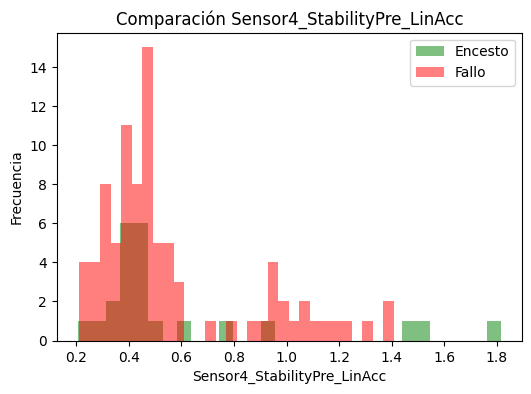

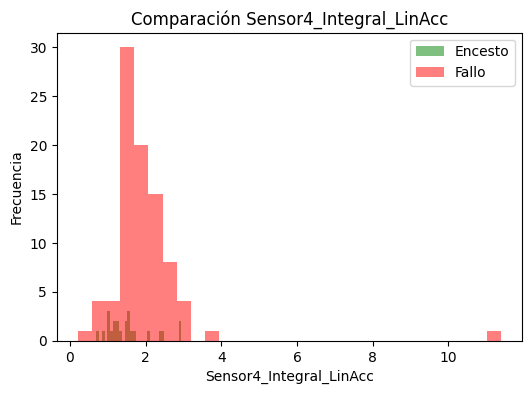

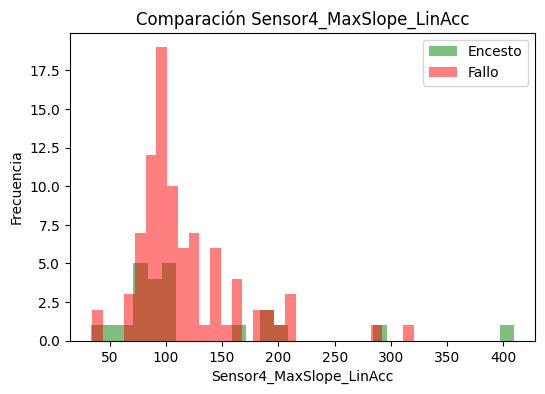

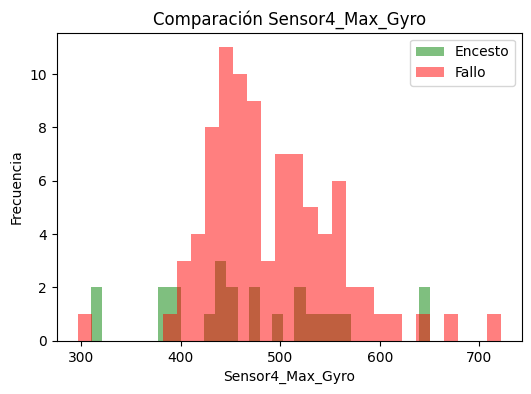

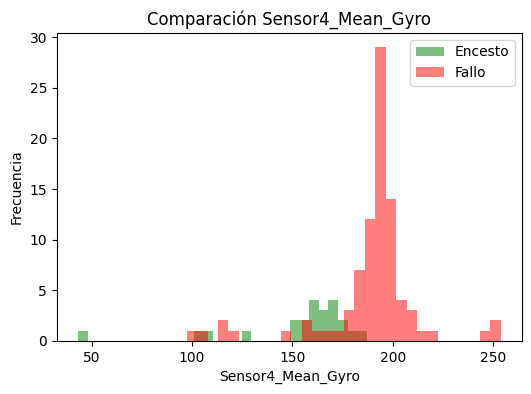

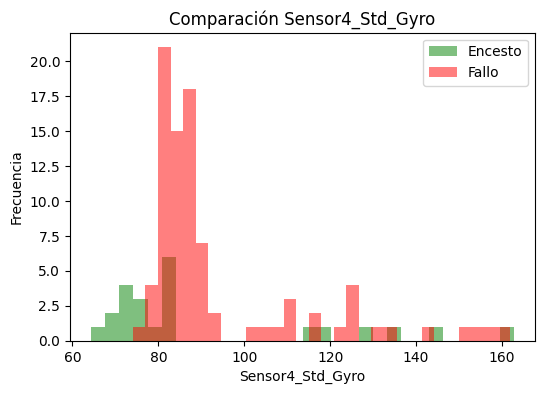

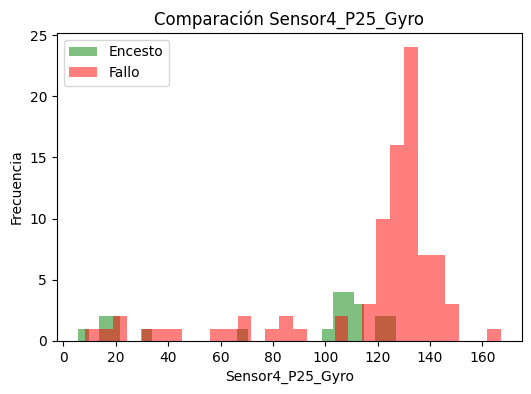

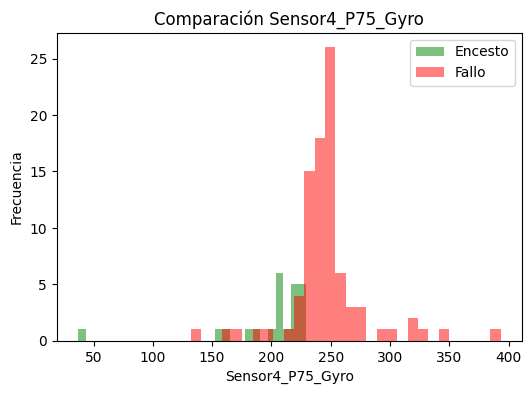

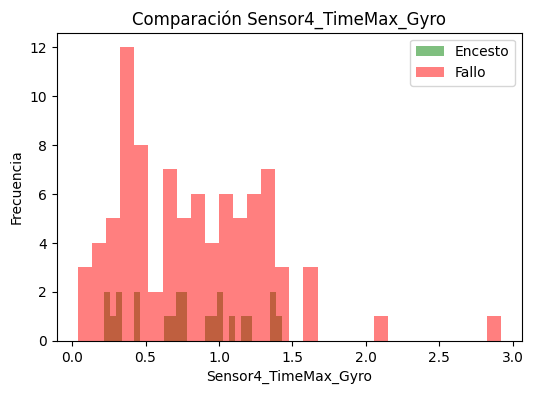

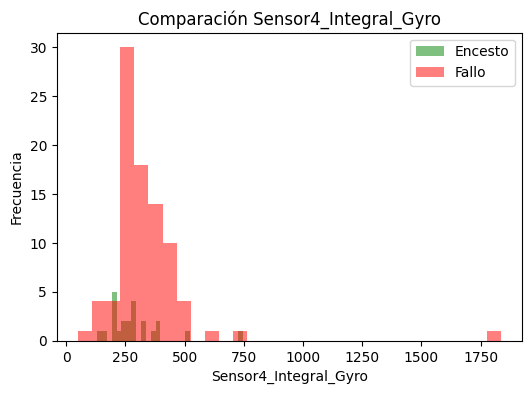

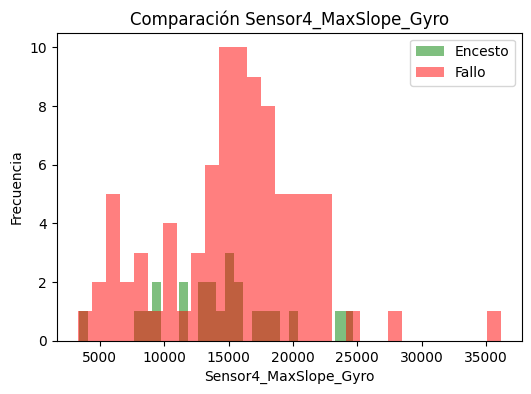

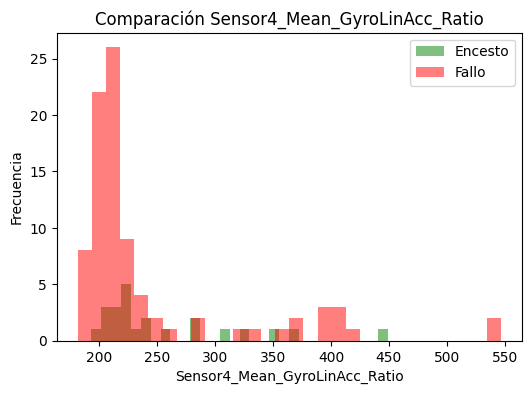

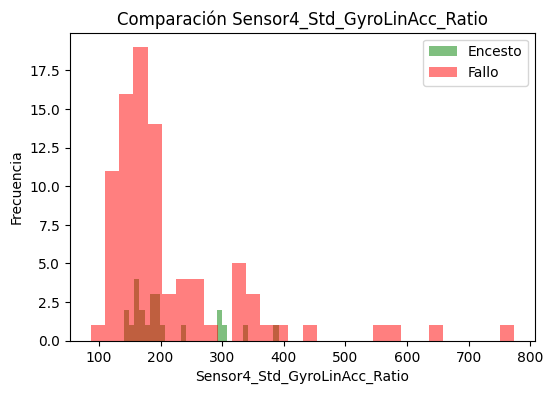

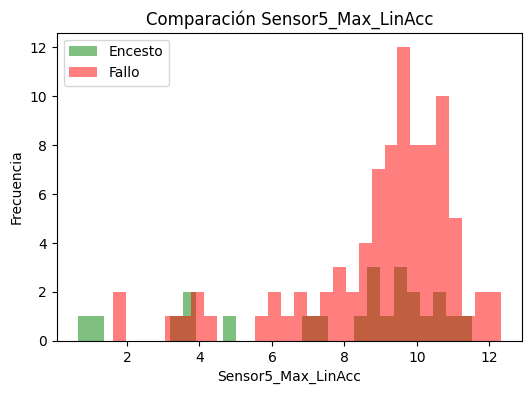

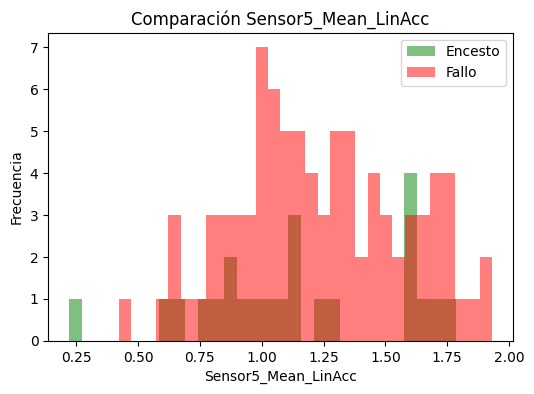

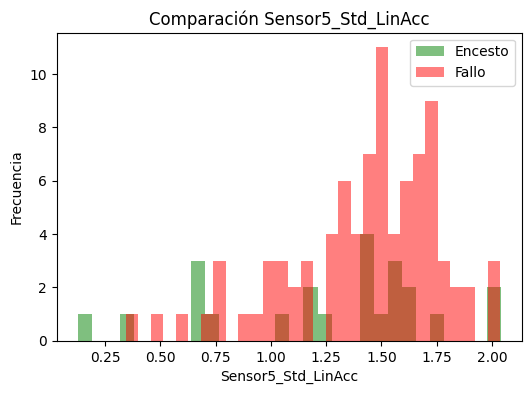

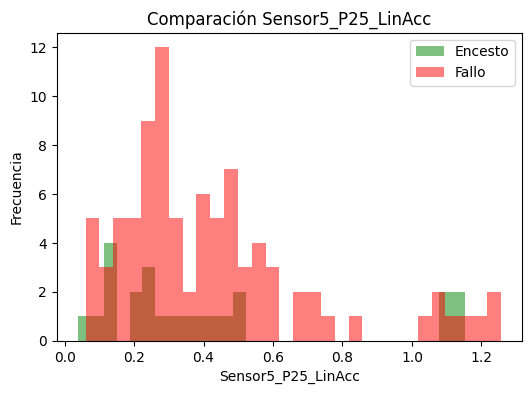

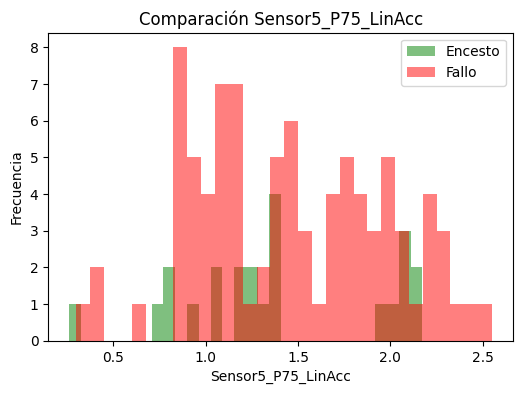

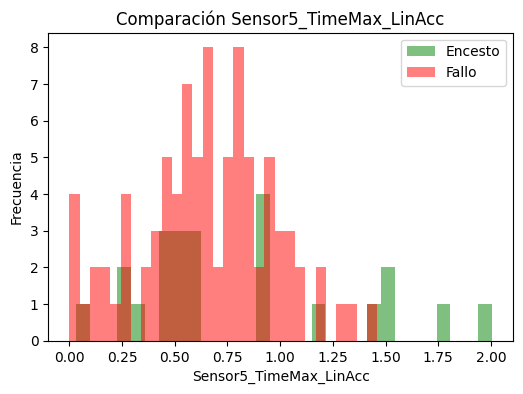

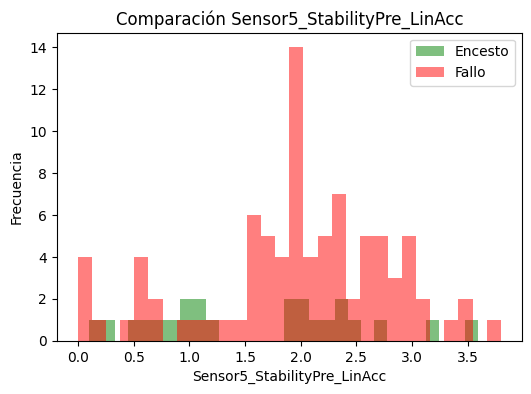

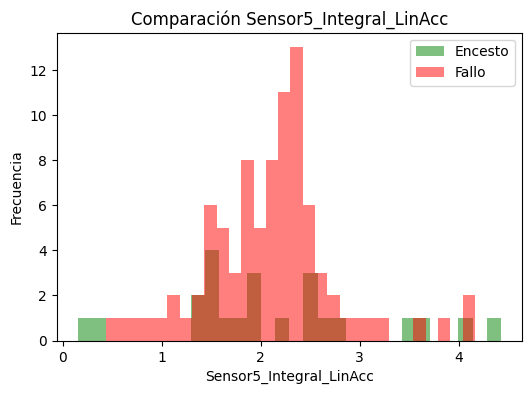

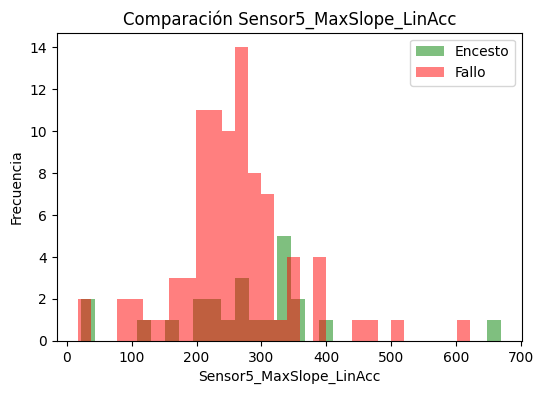

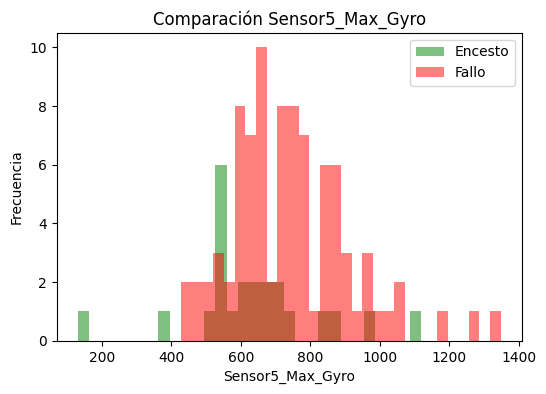

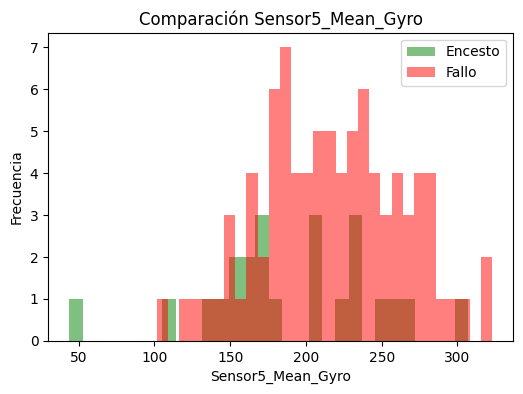

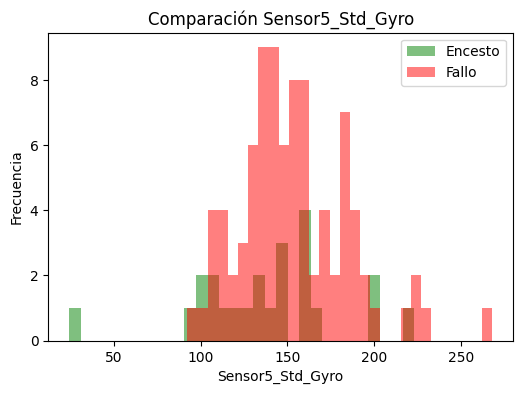

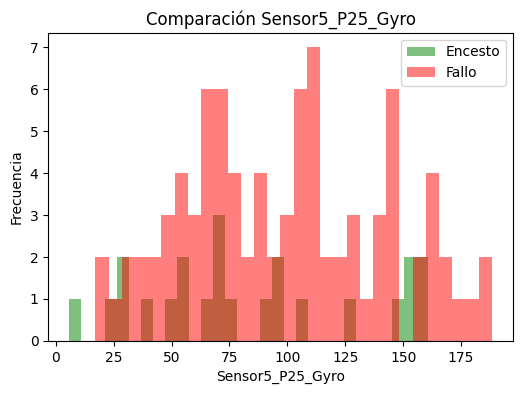

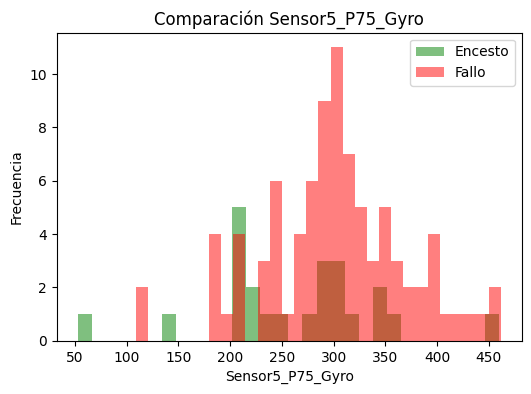

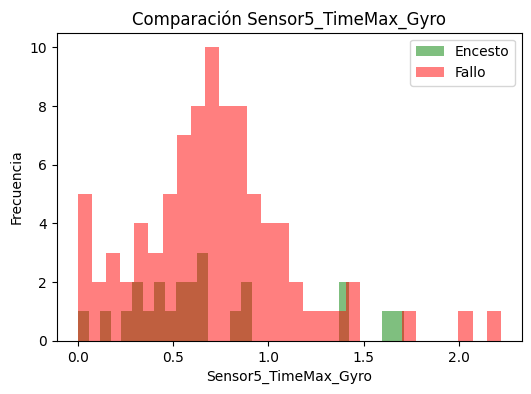

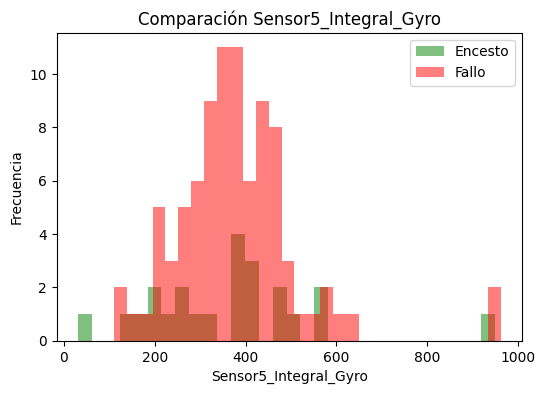

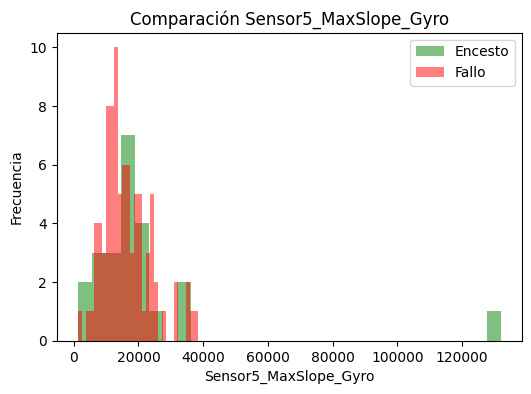

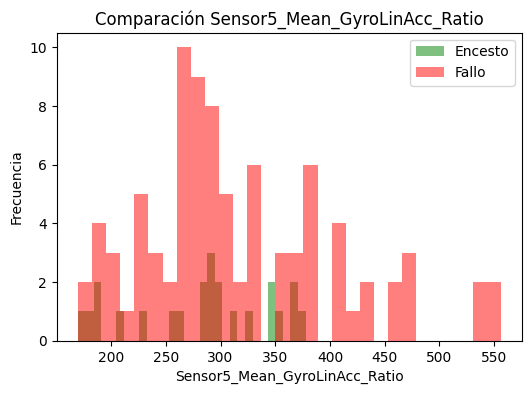

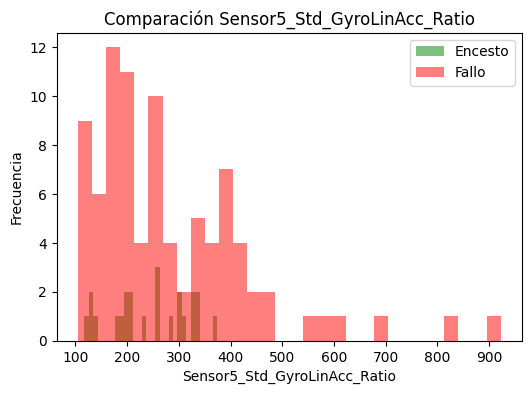

In [15]:
import matplotlib.pyplot as plt

encesto = dataset_features[dataset_features["Clase_Tiro"] == 1]
fallo = dataset_features[dataset_features["Clase_Tiro"] == 0]

features_to_plot = []

sensores = [2,4,5]
for sensor in sensores:
    features_to_plot += [
        f"Sensor{sensor}_Max_LinAcc",
        f"Sensor{sensor}_Mean_LinAcc",
        f"Sensor{sensor}_Std_LinAcc",
        f"Sensor{sensor}_P25_LinAcc",
        f"Sensor{sensor}_P75_LinAcc",
        f"Sensor{sensor}_TimeMax_LinAcc",
        f"Sensor{sensor}_StabilityPre_LinAcc",
        f"Sensor{sensor}_Integral_LinAcc",
        f"Sensor{sensor}_MaxSlope_LinAcc",
        f"Sensor{sensor}_Max_Gyro",
        f"Sensor{sensor}_Mean_Gyro",
        f"Sensor{sensor}_Std_Gyro",
        f"Sensor{sensor}_P25_Gyro",
        f"Sensor{sensor}_P75_Gyro",
        f"Sensor{sensor}_TimeMax_Gyro",
        f"Sensor{sensor}_Integral_Gyro",
        f"Sensor{sensor}_MaxSlope_Gyro",
        f"Sensor{sensor}_Mean_GyroLinAcc_Ratio",
        f"Sensor{sensor}_Std_GyroLinAcc_Ratio"
    ]

for var in features_to_plot:
    plt.figure(figsize=(6,4))

    plt.hist(encesto[var], bins=30, alpha=0.5, label="Encesto", color='g')
    plt.hist(fallo[var], bins=30, alpha=0.5, label="Fallo", color='r')

    plt.title(f"Comparación {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

Con los histogramas podemos darnos cuenta de que las variables que vamos a valuar son utiles y no solo nos daran ruido, ya que se ve una diferencia en la frecuencias de los valores cuando se encesta y cuando no.

### Crear dataset listo para modelo
Agrupar un intento por fila

In [16]:
dataset_modelo = dataset_features.groupby(
    ["Archivo","Sujeto","Intento","Clase_Tiro"]
).first().reset_index()

print(dataset_modelo.head())

        Archivo Sujeto  Intento  Clase_Tiro  Sensor2_Max_LinAcc  \
0  Edgar_01.csv  Edgar        1           0            4.256651   
1  Edgar_02.csv  Edgar        2           0            4.713544   
2  Edgar_03.csv  Edgar        3           0            4.563998   
3  Edgar_04.csv  Edgar        4           0            5.007968   
4  Edgar_05.csv  Edgar        5           0            5.391119   

   Sensor2_Mean_LinAcc  Sensor2_Std_LinAcc  Sensor2_Max_Gyro  \
0             2.130353            0.888411       1117.468164   
1             2.221437            0.909732        880.302021   
2             2.226934            0.891351        928.767781   
3             2.069528            0.867685       1014.065869   
4             2.194749            0.938019       1166.303754   

   Sensor2_Mean_Gyro  Sensor2_Std_Gyro  ...  Sensor5_P75_Gyro  \
0         417.504647        179.596634  ...        280.123168   
1         386.339106        179.397188  ...        349.977226   
2         390.907

# Entrenar modelo Random Forest

In [17]:
feature_cols = [col for col in dataset_modelo.columns if col.startswith("Sensor")]
X = dataset_modelo[feature_cols]

y = dataset_modelo["Clase_Tiro"]

### Entrenar modelo

Reporte de clasificación - Random Forest CV:
              precision    recall  f1-score   support

       Fallo       0.92      0.94      0.93        88
     Encesto       0.76      0.70      0.73        23

    accuracy                           0.89       111
   macro avg       0.84      0.82      0.83       111
weighted avg       0.89      0.89      0.89       111



<Figure size 500x500 with 0 Axes>

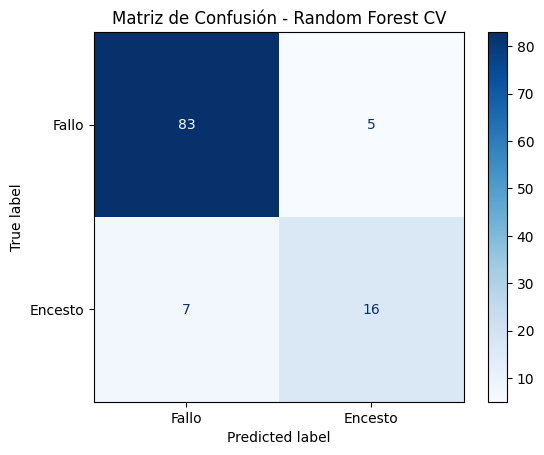

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

print("Reporte de clasificación - Random Forest CV:")
print(classification_report(y_true_all, y_pred_all, target_names=["Fallo","Encesto"]))

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo","Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - Random Forest CV")
plt.show()

### Caracteristicas mas importantes

In [19]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(100)

,0
Sensor4_P75_LinAcc,0.095607
Sensor4_Mean_Gyro,0.085197
Sensor4_Mean_LinAcc,0.083254
Sensor4_Std_LinAcc,0.076714
Sensor4_P75_Gyro,0.067909
Sensor4_P25_LinAcc,0.050315
Sensor4_P25_Gyro,0.048155
Sensor4_Std_Gyro,0.041482
Sensor4_Max_LinAcc,0.033214
Sensor4_StabilityPre_LinAcc,0.026699


### Validacion interna

F1-score: 0.889


<Figure size 500x500 with 0 Axes>

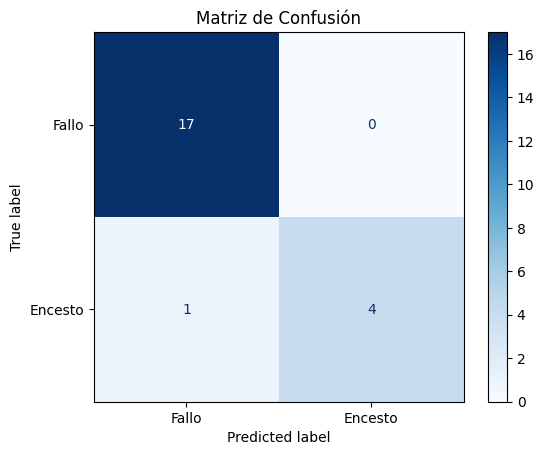

In [20]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo", "Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión")
plt.show()

# Entrenamiento de XGBoost con validación cruzada

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:26:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:26:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:26:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:26:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Reporte de clasificación (validación cruzada):
              precision    recall  f1-score   support

       Fallo       0.90      0.90      0.90        88
     Encesto       0.61      0.61      0.61        23

    accuracy                           0.84       111
   macro avg       0.75      0.75      0.75       111
weighted avg       0.84      0.84      0.84       111



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:26:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 500x500 with 0 Axes>

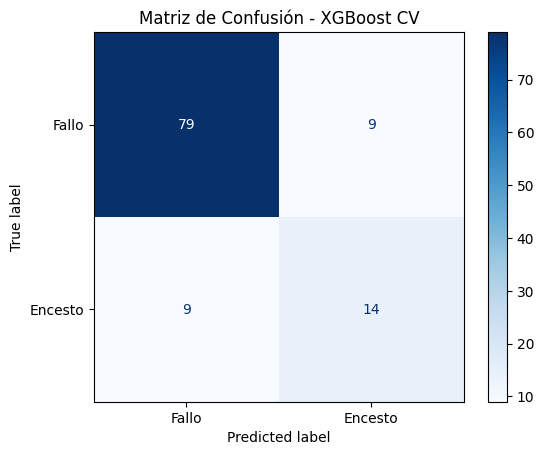

In [22]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

print("Reporte de clasificación (validación cruzada):")
print(classification_report(y_true_all, y_pred_all, target_names=["Fallo","Encesto"]))

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo","Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - XGBoost CV")
plt.show()

### Validacion interna

F1-score: 0.800


<Figure size 500x500 with 0 Axes>

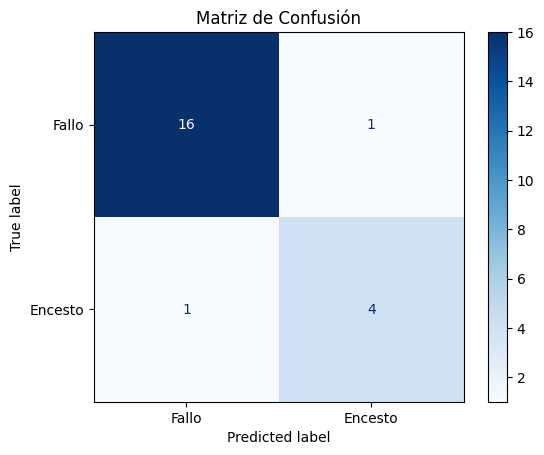

In [23]:
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo", "Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión")
plt.show()

# Gradient Boosting con validación cruzada

Reporte de clasificación - Gradient Boosting CV:
              precision    recall  f1-score   support

       Fallo       0.90      0.89      0.89        88
     Encesto       0.58      0.61      0.60        23

    accuracy                           0.83       111
   macro avg       0.74      0.75      0.74       111
weighted avg       0.83      0.83      0.83       111



<Figure size 500x500 with 0 Axes>

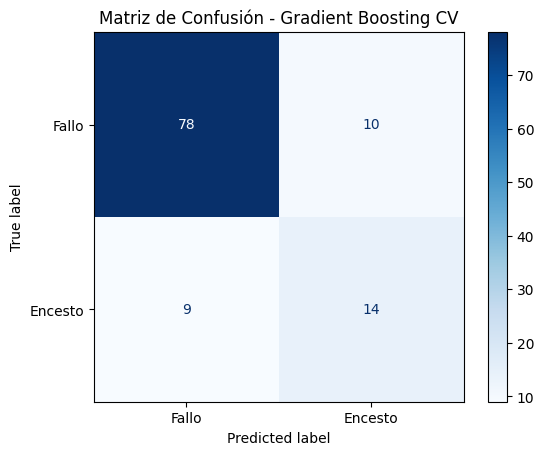

In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.2,
    max_depth=3,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    gb_model.fit(X_train, y_train)

    y_pred = gb_model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

print("Reporte de clasificación - Gradient Boosting CV:")
print(classification_report(y_true_all, y_pred_all, target_names=["Fallo","Encesto"]))

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo","Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - Gradient Boosting CV")
plt.show()

Validacion interna

F1-score: 0.667


<Figure size 500x500 with 0 Axes>

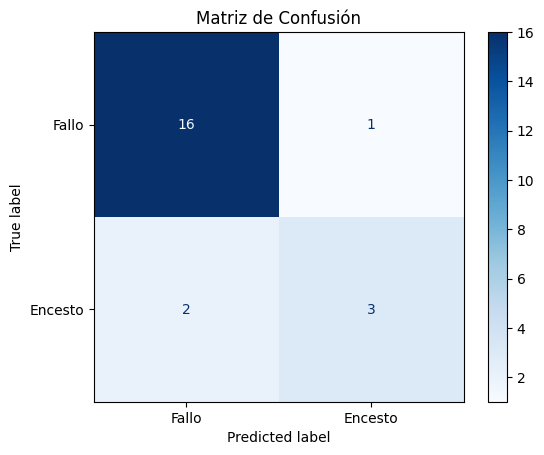

In [25]:
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo", "Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión")
plt.show()

# Logistic Regression con validación cruzada

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Reporte de clasificación - Logistic Regression CV:
              precision    recall  f1-score   support

       Fallo       0.82      0.81      0.81        88
     Encesto       0.29      0.30      0.30        23

    accuracy                           0.70       111
   macro avg       0.55      0.56      0.55       111
weighted avg       0.71      0.70      0.71       111



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<Figure size 500x500 with 0 Axes>

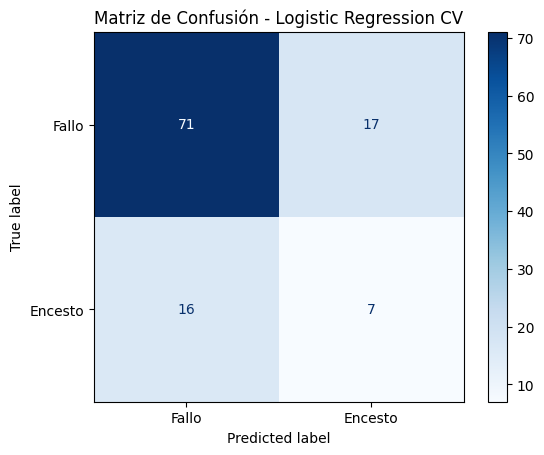

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lr_model.fit(X_train, y_train)

    y_pred = lr_model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

print("Reporte de clasificación - Logistic Regression CV:")
print(classification_report(y_true_all, y_pred_all, target_names=["Fallo","Encesto"]))

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo","Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - Logistic Regression CV")
plt.show()

Validacion interna

F1-score: 0.400


<Figure size 500x500 with 0 Axes>

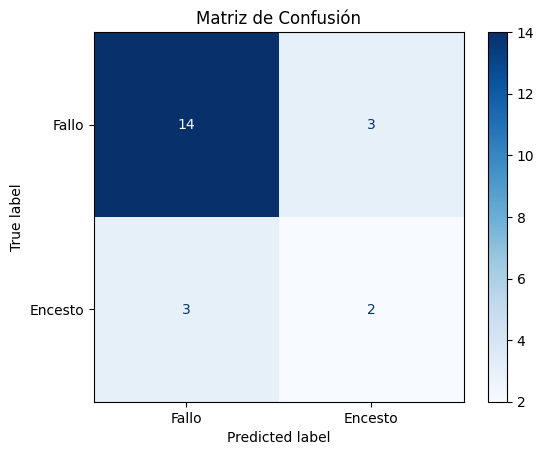

In [27]:
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo", "Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión")
plt.show()

# MLP con validación cruzada

Reporte de clasificación - MLP CV:
              precision    recall  f1-score   support

       Fallo       0.79      0.78      0.79        88
     Encesto       0.21      0.22      0.21        23

    accuracy                           0.67       111
   macro avg       0.50      0.50      0.50       111
weighted avg       0.67      0.67      0.67       111



<Figure size 500x500 with 0 Axes>

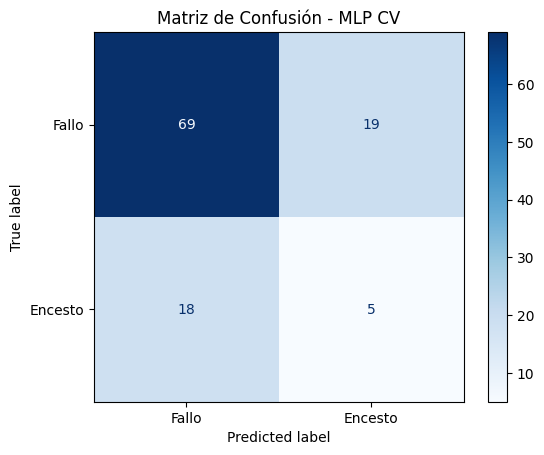

In [28]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_true_all = []
y_pred_all = []

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    mlp_model.fit(X_train, y_train)

    y_pred = mlp_model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

print("Reporte de clasificación - MLP CV:")
print(classification_report(y_true_all, y_pred_all, target_names=["Fallo","Encesto"]))

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fallo","Encesto"])

plt.figure(figsize=(5,5))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - MLP CV")
plt.show()

El modelo que mostro mejores resultados fue Random Forest. Utilizaremos este modelo para intentar hacer predicciones con el conjunto test

# Crear dataset del conjunto de validacion externa

In [51]:
import os
import pandas as pd

ruta_test = "drive/MyDrive/CDSI 2026/Inercial/test"

dfs = []

for archivo in os.listdir(ruta_test):

    if archivo == "lista_test.csv":
        continue

    if archivo.endswith(".csv"):

        nombre_base = archivo.replace(".csv", "")
        sujeto, intento = nombre_base.split("_")

        df = pd.read_csv(os.path.join(ruta_test, archivo))

        df.columns = df.columns.str.strip()

        df["Sujeto"] = sujeto
        df["Intento"] = int(intento)

        dfs.append(df)

dataset_test = pd.concat(dfs, ignore_index=True)

print(dataset_test.head())
print("\nTotal de filas:", len(dataset_test))
dataset_test.to_csv("dataset_test_completo.csv", index=False)

   SensorId  TimeStamp (s)  FrameNumber  AccX (g)  AccY (g)  AccZ (g)  \
0         5        -0.0001            0  0.574912  0.517687  0.615958   
1         5         0.0099            1  0.571776  0.514575  0.612626   
2         5         0.0199            2  0.580542  0.509047  0.613824   
3         5         0.0299            3  0.583138  0.490501  0.610350   
4         5         0.0399            4  0.575518  0.482141  0.618228   

   GyroX (deg/s)  GyroY (deg/s)  GyroZ (deg/s)  MagX (uT)  ...     QuatZ  \
0      -2.820915       2.171331      -6.693839  14.440222  ... -0.049657   
1      -1.840552       3.278456      -7.486130  14.469453  ... -0.050011   
2      -1.132860       3.486247      -7.910811  14.235603  ... -0.050343   
3      -0.652035       3.311585      -8.446879  14.235603  ... -0.050756   
4      -1.026781       4.562176      -9.902018  14.440222  ... -0.051144   

   LinAccX (g)  LinAccY (g) LinAccZ (g) Pressure (kPa)  Altitude (m)  \
0     0.010534    -0.001968   -0

# Rellenar sensores faltantes
En el caso de el conjunto de prueba que nos proporcionaron el problema es que los datos no estan clasificados como encesto y no encesto. Esto seria lo correcto en caso de que los datos estuvieran completos pero en esta ocasion los datos de los sensores no estan completos. Para este caso no puedo rellenar los datos simulados por separado los tiros encestados y los no encestados. Esto es un gran problema por que en realidad se obtendran los estadisticos de todo el conjunto por completo y los datos generados de manera sintetica seran muy generales o neutros y por lo tanto no habra una clasificacion correcta. Sin embargo se hara de este modo para poder terminar la practica y analizaremos los datos de las predicciones para ver como se comporta.

In [30]:
sensores_esperados = [2,4,5]
estadisticas_sensores_global = {}

for sensor in sensores_esperados:

    df_sensor = dataset_test[
        dataset_test["SensorId"] == sensor
    ].copy()

    for col in columnas_modelo:
        if col in df_sensor.columns:
            df_sensor[col] = pd.to_numeric(df_sensor[col], errors='coerce')

    mean = df_sensor[columnas_modelo].mean()
    std = df_sensor[columnas_modelo].std()

    std = std.replace(0, 1e-6)

    estadisticas_sensores_global[sensor] = {
        "mean": mean,
        "std": std
    }


In [42]:
test_dataset_filled_parts = []

for intento in dataset_test["Intento"].unique():

    df_intento = dataset_test[
        dataset_test["Intento"] == intento
    ]

    sensores_presentes = df_intento["SensorId"].unique()

    if len(sensores_presentes) == 0:
        continue

    sensor_ref = sensores_presentes[0]
    df_ref = df_intento[
        df_intento["SensorId"] == sensor_ref
    ].copy()

    base_tiempo = df_ref[["TimeStamp (s)", "FrameNumber"]].reset_index(drop=True)
    n_muestras = len(base_tiempo)

    for sensor in sensores_esperados:

        if sensor not in sensores_presentes:

            stats = estadisticas_sensores_global[sensor]

            safe_std = stats["std"].replace(0, 1e-6)

            datos_simulados = pd.DataFrame(
                np.random.normal(
                    loc=stats["mean"].values,
                    scale=safe_std.values,
                    size=(n_muestras, len(columnas_modelo))
                ),
                columns=columnas_modelo
            )

            datos_simulados = pd.concat([base_tiempo, datos_simulados], axis=1)

            datos_simulados["SensorId"] = sensor
            datos_simulados["Intento"] = intento

            if "Sujeto" in df_intento.columns:
                datos_simulados["Sujeto"] = df_intento["Sujeto"].iloc[0]

            test_dataset_filled_parts.append(datos_simulados)

if test_dataset_filled_parts:
    dataset_test_filled = pd.concat([dataset_test] + test_dataset_filled_parts, ignore_index=True)
else:
    dataset_test_filled = dataset_test.copy()

dataset_test_filled = dataset_test_filled.sort_values(
    by=["Intento", "SensorId", "TimeStamp (s)", "Sujeto"]
).reset_index(drop=True)


In [52]:
verificacion = dataset_test_filled.groupby(
    ["Intento", "SensorId", "Sujeto"]
).size()

print(verificacion)
dataset_test_filled.to_csv("dataset_test_filled.csv", index=False)

Intento  SensorId  Sujeto
1        1         Tony      420
         2         Tony      160
         4         Joan      313
         5         Joan      105
                   Tony      208
                            ... 
19       4         Joan      200
         5         Joan      239
20       2         Joan      105
         4         Joan      105
         5         Joan      105
Length: 81, dtype: int64


# Extraer caracteristicas al conjunto test

In [53]:
features = []
sensores = [2,4,5]

for (sujeto, intento), df_intento in dataset_test_filled.groupby(["Sujeto", "Intento"]):

    df_intento = df_intento.copy()

    feat_intento = {
        "Sujeto": sujeto,
        "Intento": intento
    }

    if sujeto is not None:
        feat_intento["Sujeto"] = sujeto

    for col in ["LinAccX (g)", "LinAccY (g)", "LinAccZ (g)", "GyroX (deg/s)", "GyroY (deg/s)", "GyroZ (deg/s)"]:
        if col in df_intento.columns:
            df_intento[col] = pd.to_numeric(df_intento[col], errors='coerce')

    df_intento["LinAcc_mag"] = np.sqrt(
        df_intento["LinAccX (g)"]**2 +
        df_intento["LinAccY (g)"]**2 +
        df_intento["LinAccZ (g)"]**2
    )

    df_intento["Gyro_mag"] = np.sqrt(
        df_intento["GyroX (deg/s)"]**2 +
        df_intento["GyroY (deg/s)"]**2 +
        df_intento["GyroZ (deg/s)"]**2
    )

    for sensor in sensores:

        df_sensor = df_intento[
            df_intento["SensorId"] == sensor
        ].copy()

        if len(df_sensor) == 0:
            continue

        linacc = df_sensor["LinAcc_mag"].values
        gyro = df_sensor["Gyro_mag"].values
        time = df_sensor["TimeStamp (s)"].values

        feat_intento[f"Sensor{sensor}_Max_LinAcc"] = linacc.max()
        feat_intento[f"Sensor{sensor}_Mean_LinAcc"] = linacc.mean()
        feat_intento[f"Sensor{sensor}_Std_LinAcc"] = linacc.std()

        feat_intento[f"Sensor{sensor}_Max_Gyro"] = gyro.max()
        feat_intento[f"Sensor{sensor}_Mean_Gyro"] = gyro.mean()
        feat_intento[f"Sensor{sensor}_Std_Gyro"] = gyro.std()

        feat_intento[f"Sensor{sensor}_P25_LinAcc"] = np.percentile(linacc, 25)
        feat_intento[f"Sensor{sensor}_P75_LinAcc"] = np.percentile(linacc, 75)

        feat_intento[f"Sensor{sensor}_P25_Gyro"] = np.percentile(gyro, 25)
        feat_intento[f"Sensor{sensor}_P75_Gyro"] = np.percentile(gyro, 75)

        idx_max_linacc = linacc.argmax()
        feat_intento[f"Sensor{sensor}_TimeMax_LinAcc"] = time[idx_max_linacc]

        idx_max_gyro = gyro.argmax()
        feat_intento[f"Sensor{sensor}_TimeMax_Gyro"] = time[idx_max_gyro]

        pre_window = linacc[max(0, idx_max_linacc-10):idx_max_linacc]
        feat_intento[f"Sensor{sensor}_StabilityPre_LinAcc"] = pre_window.std() if len(pre_window)>0 else 0

        ratio = gyro / np.where(linacc==0, 1e-6, linacc)
        feat_intento[f"Sensor{sensor}_Mean_GyroLinAcc_Ratio"] = ratio.mean()
        feat_intento[f"Sensor{sensor}_Std_GyroLinAcc_Ratio"] = ratio.std()

        feat_intento[f"Sensor{sensor}_Integral_LinAcc"] = np.trapezoid(linacc, time)
        feat_intento[f"Sensor{sensor}_MaxSlope_LinAcc"] = np.max(np.gradient(linacc, time))

        feat_intento[f"Sensor{sensor}_Integral_Gyro"] = np.trapezoid(gyro, time)
        feat_intento[f"Sensor{sensor}_MaxSlope_Gyro"] = np.max(np.gradient(gyro, time))

    features.append(feat_intento)

dataset_features_entrenamiento = pd.DataFrame(features)

# Prediccion

In [54]:
X_test = dataset_features_entrenamiento[feature_cols]

y_pred = rf_model.predict(X_test)

y_proba = rf_model.predict_proba(X_test)

dataset_features_entrenamiento["Prediccion"] = y_pred
dataset_features_entrenamiento["Prob_NoEncesto"] = y_proba[:, 0]
dataset_features_entrenamiento["Prob_Encesto"] = y_proba[:, 1]

In [56]:
dataset_features_entrenamiento[
    ["Sujeto","Intento", "Prediccion", "Prob_NoEncesto", "Prob_Encesto"]
].head(100)

,Sujeto,Intento,Prediccion,Prob_NoEncesto,Prob_Encesto
0,Joan,1,0,0.975,0.025
1,Joan,2,0,0.635,0.365
2,Joan,3,0,0.755,0.245
3,Joan,4,0,0.970,0.030
4,Joan,5,0,0.955,0.045
5,Joan,6,0,0.645,0.355
6,Joan,7,0,1.000,0.000
7,Joan,8,0,0.560,0.440
8,Joan,9,0,0.905,0.095
9,Joan,10,0,1.000,0.000
